# Projet 12 - ZenAssist : Étape 3 - Évaluation de l'approche Machine Learning Traditionnel

Ce notebook met en œuvre et évalue l'approche basée sur le **Machine Learning supervisé classique** (Vectorisation TF-IDF + Classifieurs) pour la classification des réclamations clients ZenAssist.

### Objectifs :
1. **Vectoriser les réclamations textuelles** avec `TfidfVectorizer` (Unigrammes & Bigrammes).
2. **Encoder la variable cible (`Tag_Clean`)** avec `LabelEncoder`.
3. **Entraîner et comparer plusieurs classifieurs** sur le dataset d'entraînement (`dataset/processed_train.csv`) :
   * Régression Logistique (`LogisticRegression`)
   * Naive Bayes Multinomial (`MultinomialNB`)
   * Linear SVM (`SGDClassifier`)
4. **Évaluer la performance à iso-périmètre** sur l'échantillon de **1 000 réclamations** (`dataset/llm_test_sample.csv`) pour une comparaison directe 1-à-1 avec Gemini 3.5 Flash Lite.
5. **Évaluer la robustesse à grande échelle** sur l'ensemble du dataset de test (**73 425 réclamations**).
6. **Mesurer la latence d'inférence (temps de réponse par ticket en ms)**.
7. **Générer le tableau comparatif, la matrice de confusion et sauvegarder le meilleur modèle**.

In [1]:
import os
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

## 1. Chargement des jeux de données

In [2]:
train_path = 'dataset/processed_train.csv'
test_path = 'dataset/processed_test.csv'
llm_sample_path = 'dataset/llm_test_sample.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_llm_sample = pd.read_csv(llm_sample_path)

print(f'Train Set : {len(df_train):,} exemples')
print(f'Test Set Complet : {len(df_test):,} exemples')
print(f'LLM Test Sample : {len(df_llm_sample):,} exemples')

X_train_raw = df_train['Consumer Claim'].astype(str).fillna('')
y_train_raw = df_train['Tag_Clean']

X_test_raw = df_test['Consumer Claim'].astype(str).fillna('')
y_test_raw = df_test['Tag_Clean']

X_llm_raw = df_llm_sample['Consumer Claim'].astype(str).fillna('')
y_llm_raw = df_llm_sample['Tag_Clean']

Train Set : 293,698 exemples
Test Set Complet : 73,425 exemples
LLM Test Sample : 1,000 exemples


## 2. Encodage des étiquettes (`LabelEncoder`)

In [3]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
y_llm = label_encoder.transform(y_llm_raw)

CATEGORIES = list(label_encoder.classes_)
print(f'Nombre de catégories ({len(CATEGORIES)}) :')
for i, cat in enumerate(CATEGORIES, 1):
    print(f' {i:2d}. {cat}')

Nombre de catégories (10) :
  1. Bank account / Savings
  2. Credit card / Prepaid card
  3. Credit reporting
  4. Debt collection
  5. Money transfer / Crypto
  6. Mortgage
  7. Other financial service
  8. Payday & Personal loan
  9. Student loan
 10. Vehicle loan / Lease


## 3. Vectorisation TF-IDF (`TfidfVectorizer`)

In [4]:
print('Transformation des réclamations textuelles en matrice numérique TF-IDF...')
start_vec = time.time()

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_test_tfidf = vectorizer.transform(X_test_raw)
X_llm_tfidf = vectorizer.transform(X_llm_raw)

duration_vec = time.time() - start_vec
print(f'Vectorisation terminée en {duration_vec:.2f} s. Dimension du vocabulaire : {X_train_tfidf.shape}')

Transformation des réclamations textuelles en matrice numérique TF-IDF...
Vectorisation terminée en 112.85 s. Dimension du vocabulaire : (293698, 50000)


## 4. Entraînement et Évaluation des Modèles ML

In [5]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=500, n_jobs=-1, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM (SGD)': SGDClassifier(loss='log_loss', penalty='l2', max_iter=500, random_state=42, n_jobs=-1)
}

results = []
best_model = None
best_model_name = ''
best_f1 = 0.0
best_y_pred_llm = None

for name, model in models.items():
    print(f'\n---> Entraînement du modèle : {name}...')
    start_train = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_train
    
    # Prédiction sur l'échantillon 1,000 LLM
    start_inf = time.perf_counter()
    y_pred_llm = model.predict(X_llm_tfidf)
    inf_duration = time.perf_counter() - start_inf
    latency_per_sample_ms = (inf_duration / len(X_llm_raw)) * 1000  # ms/ticket
    
    acc_llm = accuracy_score(y_llm, y_pred_llm)
    f1_llm_weighted = f1_score(y_llm, y_pred_llm, average='weighted')
    
    # Prédiction sur le Test set complet (73,425)
    y_pred_full = model.predict(X_test_tfidf)
    acc_full = accuracy_score(y_test, y_pred_full)
    f1_full_weighted = f1_score(y_test, y_pred_full, average='weighted')
    
    print(f'     Accuracy (1k LLM sample)  : {acc_llm * 100:.2f}%')
    print(f'     F1-score Weighted (1k)    : {f1_llm_weighted:.4f}')
    print(f'     Accuracy (73k Test set)   : {acc_full * 100:.2f}%')
    print(f'     Latence d\'inférence       : {latency_per_sample_ms:.4f} ms / ticket')
    
    results.append({
        'Modèle': name,
        'Accuracy (1k LLM)': f'{acc_llm*100:.2f}%',
        'F1-Weighted (1k)': round(f1_llm_weighted, 4),
        'Accuracy (73k Test)': f'{acc_full*100:.2f}%',
        'F1-Weighted (73k)': round(f1_full_weighted, 4),
        'Temps Entraînement (s)': round(train_time, 2),
        'Latence / ticket (ms)': round(latency_per_sample_ms, 4)
    })
    
    if f1_llm_weighted > best_f1:
        best_f1 = f1_llm_weighted
        best_model = model
        best_model_name = name
        best_y_pred_llm = y_pred_llm


---> Entraînement du modèle : Logistic Regression...


/home/obarthe/Bureau/Formation_Dev_IA/Projet12/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


     Accuracy (1k LLM sample)  : 85.70%
     F1-score Weighted (1k)    : 0.8548
     Accuracy (73k Test set)   : 84.72%
     Latence d'inférence       : 0.0018 ms / ticket

---> Entraînement du modèle : Multinomial Naive Bayes...
     Accuracy (1k LLM sample)  : 82.20%
     F1-score Weighted (1k)    : 0.8196
     Accuracy (73k Test set)   : 81.54%
     Latence d'inférence       : 0.0026 ms / ticket

---> Entraînement du modèle : Linear SVM (SGD)...
     Accuracy (1k LLM sample)  : 79.60%
     F1-score Weighted (1k)    : 0.7800
     Accuracy (73k Test set)   : 80.16%
     Latence d'inférence       : 0.0079 ms / ticket


## 5. Tableau Comparatif des Modèles Machine Learning

In [6]:
df_res = pd.DataFrame(results)
display(df_res)
df_res.to_csv('dataset/ml_comparison_metrics.csv', index=False)

,Modèle,Accuracy (1k LLM),F1-Weighted (1k),Accuracy (73k Test),F1-Weighted (73k),Temps Entraînement (s),Latence / ticket (ms)
0,Logistic Regression,85.70%,0.8548,84.72%,0.8445,228.43,0.0018
1,Multinomial Naive Bayes,82.20%,0.8196,81.54%,0.8128,0.43,0.0026
2,Linear SVM (SGD),79.60%,0.7800,80.16%,0.7871,6.94,0.0079


## 6. Rapport de Classification & Matrice de Confusion du Meilleur Modèle ML

RÉSULTATS DÉTAILLÉS : Logistic Regression
                            precision    recall  f1-score   support

    Bank account / Savings       0.84      0.83      0.83        75
Credit card / Prepaid card       0.84      0.88      0.86       113
          Credit reporting       0.85      0.88      0.87       300
           Debt collection       0.85      0.87      0.86       230
   Money transfer / Crypto       0.78      0.74      0.76        19
                  Mortgage       0.94      0.93      0.94       144
   Other financial service       0.00      0.00      0.00         1
    Payday & Personal loan       0.73      0.56      0.63        43
              Student loan       0.87      0.90      0.88        59
      Vehicle loan / Lease       0.67      0.50      0.57        16

                  accuracy                           0.86      1000
                 macro avg       0.74      0.71      0.72      1000
              weighted avg       0.85      0.86      0.85      1000



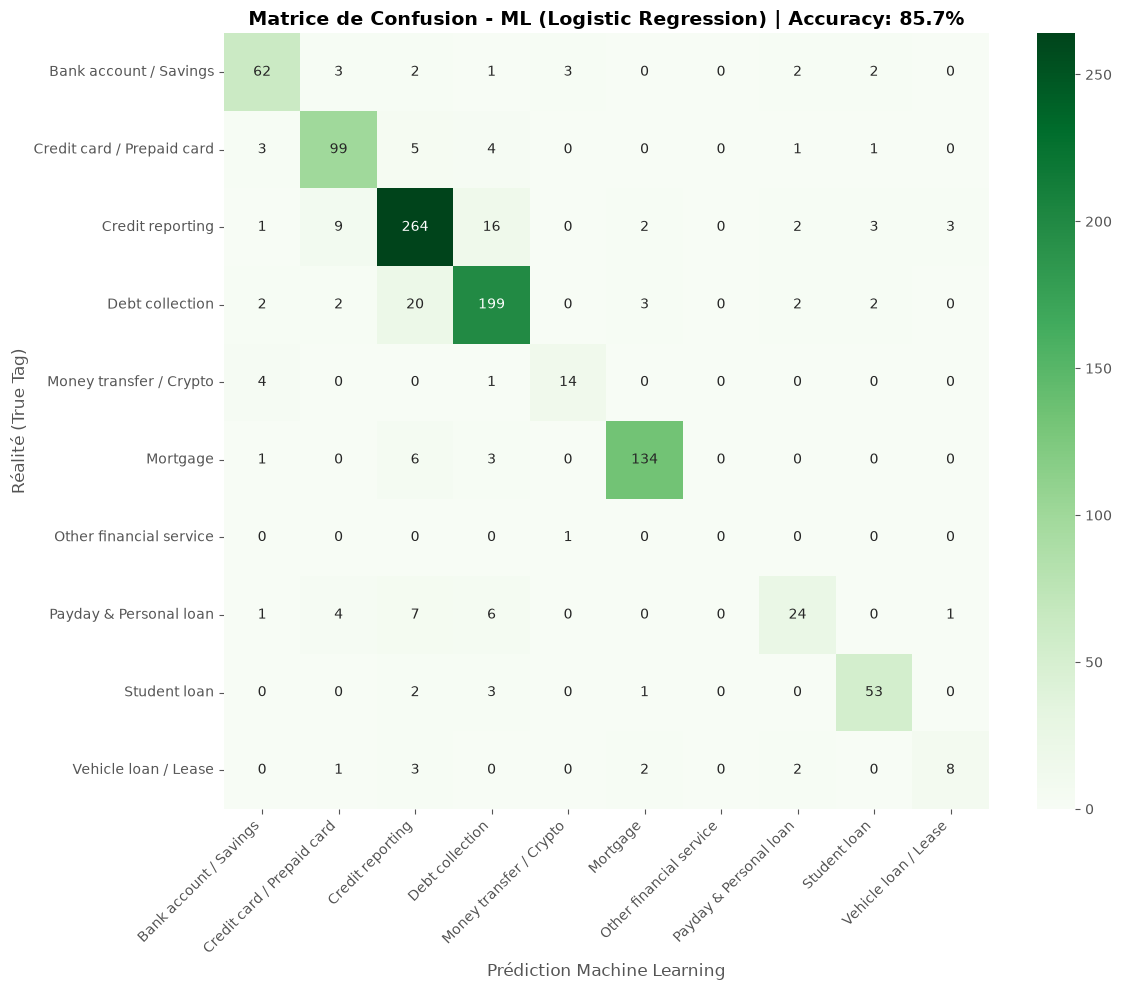

In [7]:
y_llm_names = label_encoder.inverse_transform(y_llm)
y_pred_names = label_encoder.inverse_transform(best_y_pred_llm)

print('=' * 60)
print(f'RÉSULTATS DÉTAILLÉS : {best_model_name}')
print('=' * 60)
print(classification_report(y_llm_names, y_pred_names, zero_division=0))

cm = confusion_matrix(y_llm_names, y_pred_names, labels=CATEGORIES)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title(f'Matrice de Confusion - ML ({best_model_name}) | Accuracy: {accuracy_score(y_llm, best_y_pred_llm)*100:.1f}%', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction Machine Learning')
plt.ylabel('Réalité (True Tag)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('dataset/ml_confusion_matrix.png', dpi=300)
plt.show()

## 7. Sauvegarde du modèle et du vectoriseur

In [8]:
joblib.dump(best_model, 'dataset/best_ml_model.joblib')
joblib.dump(vectorizer, 'dataset/tfidf_vectorizer.joblib')
joblib.dump(label_encoder, 'dataset/label_encoder.joblib')
print('Modèle ML, Vectoriseur TF-IDF et LabelEncoder sauvegardés sous dataset/ !')

Modèle ML, Vectoriseur TF-IDF et LabelEncoder sauvegardés sous dataset/ !
